In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\k9481\OneDrive\Documents\ml databases\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Select numeric features
X=df.select_dtypes(include=['int64','float64']).drop('Attrition',axis=1,errors='ignore')

In [10]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [11]:
#Scale
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [12]:
#Linkage
linkage_matrix=linkage(X_scaled,method='ward')

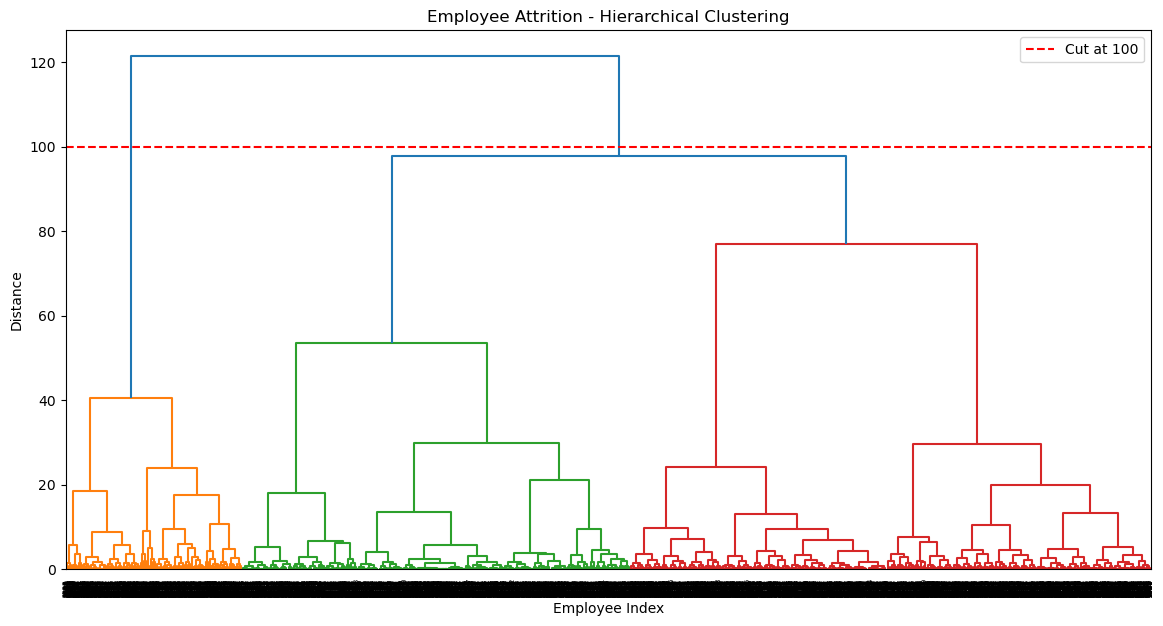

In [14]:
# Dendrogram

plt.figure(figsize=(14,7))
dendrogram(linkage_matrix)
plt.title('Employee Attrition - Hierarchical Clustering')
plt.xlabel('Employee Index')
plt.ylabel('Distance')
plt.axhline(y=100, color='red', linestyle='--', label='Cut at 100')
plt.legend()
plt.show()


In [17]:
# Train with K=4

model=AgglomerativeClustering(n_clusters=4,linkage='ward')
df['Cluster']=model.fit_predict(X_scaled)
# Select numeric columns only
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Show first few numeric columns
print(numeric_cols[:10])

# Analyze with available columns
print(df.groupby('Cluster')[numeric_cols[:5]].mean())


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Cluster']
         SeniorCitizen     tenure  MonthlyCharges  Cluster
Cluster                                                   
0                  0.0  25.060666       31.743755      0.0
1                  1.0  33.295972       79.820359      1.0
2                  0.0  60.061772       86.747873      2.0
3                  0.0  14.249549       81.806765      3.0
